In [2]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

import scarlet.reduction.stitching as st

def load_txt_curve(path: Path) -> st.SASCurve:
    """Load one ASCII I(Q) export with columns Q, I, dI, dQ."""
    data = np.loadtxt(path)
    data = data[data[:, 1] > 0]
    return st.SASCurve(
        data[:, 0],
        data[:, 1],
        data[:, 2],
        data[:, 3],
        name=path.stem,
        config_id=path.stem,
    )

def load_grasp_curve(path: Path) -> st.SASCurve:
    """Load one GRASP ASCII I(Q) export with columns Q, I, dI, dQ."""
    data = np.loadtxt(path, skiprows=40)
    data = data[data[:, 1] > 0]
    return st.SASCurve(
        data[:, 0],
        data[:, 1],
        data[:, 2],
        data[:, 3],
        name=path.stem,
        config_id=path.stem,
    )


def plot_curves(curves: tuple[st.SASCurve, ...]) -> None:
    """Plot the curves."""
    fig, ax = plt.subplots()
    for curve in curves:
        if hasattr(curve, "name"):
            name = curve.name
        else:
            name = ""
        ax.errorbar(
            curve.q,
            curve.i,
            yerr=curve.di,
            label=name,
            fmt="o",
            markersize=3,
        )
    ax.set_xlabel("Q (1/Å)")
    ax.set_ylabel("I(Q) (cm⁻¹)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend()
    # plt.show()
    return fig, ax

In [59]:
import numpy as np
from scipy.interpolate import PchipInterpolator


def interpolate_log_intensity(q_source, i_source, q_eval):
    q_source = np.asarray(q_source, dtype=float)
    i_source = np.asarray(i_source, dtype=float)
    q_eval = np.asarray(q_eval, dtype=float)

    valid = (q_source > 0) & (i_source > 0)
    interpolator = PchipInterpolator(
        np.log(q_source[valid]),
        np.log(i_source[valid]),
        extrapolate=False,
    )
    return np.exp(interpolator(np.log(q_eval)))


def compute_log_ratio_on_overlap(curve_a, curve_b, q_range=None):
    q_min = max(np.min(curve_a.q), np.min(curve_b.q))
    q_max = min(np.max(curve_a.q), np.max(curve_b.q))

    if q_range is not None:
        q_min = max(q_min, q_range[0])
        q_max = min(q_max, q_range[1])

    mask_a = (
        (curve_a.q >= q_min)
        & (curve_a.q <= q_max)
        & (curve_a.i > 0)
        & (curve_a.di > 0)
    )

    q = curve_a.q[mask_a]
    ia = curve_a.i[mask_a]
    dia = curve_a.di[mask_a]

    ib = interpolate_log_intensity(curve_b.q, curve_b.i, q)
    dib = np.interp(q, curve_b.q, curve_b.di)

    valid = (
        np.isfinite(ib)
        & np.isfinite(dib)
        & (ib > 0)
        & (dib > 0)
    )

    q = q[valid]
    ia = ia[valid]
    dia = dia[valid]
    ib = ib[valid]
    dib = dib[valid]

    log_ratio = np.log(ia) - np.log(ib)

    log_ratio_error = np.sqrt(
        (dia / ia) ** 2
        + (dib / ib) ** 2
    )

    return q, log_ratio, log_ratio_error

def weighted_constant_fit(y, yerr):
    weights = 1.0 / yerr**2
    level = np.sum(weights * y) / np.sum(weights)
    level_error = np.sqrt(1.0 / np.sum(weights))

    residual = y - level
    chi2 = np.sum(weights * residual**2)
    chi2_red = chi2 / max(y.size - 1, 1)

    return level, level_error, chi2_red


def weighted_slope(x, y, yerr):
    weights = 1.0 / yerr**2
    x0 = np.sum(weights * x) / np.sum(weights)
    y0 = np.sum(weights * y) / np.sum(weights)

    dx = x - x0
    dy = y - y0

    slope = np.sum(weights * dx * dy) / np.sum(weights * dx**2)

    slope_error = np.sqrt(1.0 / np.sum(weights * dx**2))

    return slope, slope_error


def find_best_flat_ratio_region(
    q,
    log_ratio,
    log_ratio_error,
    *,
    min_points=5,
    min_log_width=0.1,
    slope_weight=1,
    width_weight=0.05,
):
    x = np.log(q)
    n = q.size

    best = None

    for i0 in range(0, n - min_points + 1):
        for i1 in range(i0 + min_points, n + 1):
            xw = x[i0:i1]
            yw = log_ratio[i0:i1]
            ew = log_ratio_error[i0:i1]

            log_width = xw[-1] - xw[0]
            if log_width < min_log_width:
                continue

            level, level_error, chi2_red = weighted_constant_fit(yw, ew)
            slope, slope_error = weighted_slope(xw, yw, ew)

            slope_z = abs(slope / slope_error) if slope_error > 0 else np.inf

            score = (
                chi2_red
                + slope_weight * slope_z**2
                + width_weight / log_width
            )

            candidate = {
                "i0": i0,
                "i1": i1,
                "q_min": float(q[i0]),
                "q_max": float(q[i1 - 1]),
                "log_scale": float(level),
                "log_scale_error": float(level_error),
                "scale": float(np.exp(level)),
                "scale_error": float(np.exp(level) * level_error),
                "chi2_red": float(chi2_red),
                "slope": float(slope),
                "slope_error": float(slope_error),
                "slope_z": float(slope_z),
                "score": float(score),
                "n_points": int(i1 - i0),
                "log_width": float(log_width),
            }

            if best is None or candidate["score"] < best["score"]:
                best = candidate

    if best is None:
        raise RuntimeError("No acceptable flat-ratio region found.")

    return best

def stitch_without_dq(
    curve_a,
    curve_b,
    *,
    q_range=None,
    min_points=8,
    min_log_width=0.1,
    keep_fraction=0.25,
):
    q, log_ratio, log_ratio_error = compute_log_ratio_on_overlap(
        curve_a,
        curve_b,
        q_range=q_range,
    )

    best = find_best_flat_ratio_region(
        q,
        log_ratio,
        log_ratio_error,
        min_points=min_points,
        min_log_width=min_log_width,
    )

    scale = best["scale"]
    scale_error = best["scale_error"]

    q_fit_min = best["q_min"]
    q_fit_max = best["q_max"]

    # Small final overlap kept in the center of the selected fit region.
    log_min = np.log(q_fit_min)
    log_max = np.log(q_fit_max)
    log_mid = 0.5 * (log_min + log_max)
    half_keep = 0.5 * keep_fraction * (log_max - log_min)

    q_keep_min = np.exp(log_mid - half_keep)
    q_keep_max = np.exp(log_mid + half_keep)

    # Assume curve_a is low-Q reference and curve_b is high-Q curve.
    keep_a = curve_a.q <= q_keep_max
    keep_b = curve_b.q >= q_keep_min

    q_final = np.concatenate([
        curve_a.q[keep_a],
        curve_b.q[keep_b],
    ])

    i_final = np.concatenate([
        curve_a.i[keep_a],
        scale * curve_b.i[keep_b],
    ])

    di_final = np.concatenate([
        curve_a.di[keep_a],
        scale * curve_b.di[keep_b],
    ])

    dq_final = np.concatenate([
        curve_a.dq[keep_a],
        curve_b.dq[keep_b],
    ])

    order = np.argsort(q_final)

    stitched = np.column_stack([
        q_final[order],
        i_final[order],
        di_final[order],
        dq_final[order],
    ])

    return {
        "curve": stitched,
        "scale_factor": scale,
        "scale_error": scale_error,
        "fit_region": (q_fit_min, q_fit_max),
        "keep_region": (q_keep_min, q_keep_max),
        "diagnostics": best,
        "log_ratio_q": q,
        "log_ratio": log_ratio,
        "log_ratio_error": log_ratio_error,
    }


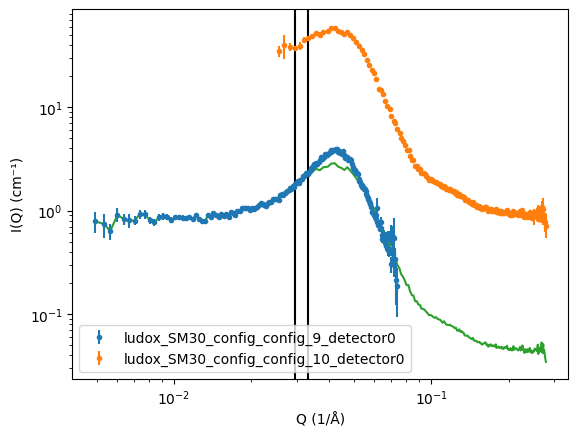

In [60]:
data_dir = Path("./data_SANS_LLB/")
curve_paths = (
    data_dir / "ludox_SM30_config_config_9_detector0.txt",
    data_dir / "ludox_SM30_config_config_10_detector0.txt",
)
curves = tuple(sorted((load_txt_curve(path) for path in curve_paths), key=lambda curve: curve.q.min()))

# data_dir = Path("./data_D11_AA0//")
# curve_paths = (
#     data_dir / "011334_001.dat",
#     data_dir / "011344_002.dat",
# )

# curves = tuple(sorted((load_grasp_curve(path) for path in curve_paths), key=lambda curve: curve.q.min()))



fig, ax = plot_curves(curves)
ans2 = stitch_without_dq(curves[0], curves[1], q_range=[0.04, 0.06])
ans = stitch_without_dq(curves[0], curves[1])
ax.plot(ans['curve'][:,0], ans['curve'][:,1])
ax.vlines(ans['diagnostics']['q_min'], 0.00111, 1000, 'k')
ax.vlines(ans['diagnostics']['q_max'], 0.00111, 1000, 'k')
plt.show()

In [51]:
ans

{'curve': array([[0.00493298, 0.78599058, 0.17543322, 0.00567309],
        [0.00535319, 0.74114105, 0.19295576, 0.00567394],
        [0.00565185, 0.63198352, 0.11691238, 0.00567459],
        ...,
        [0.27490136, 0.06207331, 0.010751  , 0.01662568],
        [0.27700843, 0.05316638, 0.0106973 , 0.01670396],
        [0.27918208, 0.04773362, 0.01109504, 0.01678494]], shape=(299, 4)),
 'scale_factor': 1.3575832020958194,
 'scale_error': 0.015324776244295128,
 'fit_region': (0.04196727115860545, 0.046430720008109994),
 'keep_region': (np.float64(0.043588431222927784),
  np.float64(0.04470384829185318)),
 'diagnostics': {'i0': 5,
  'i1': 19,
  'q_min': 0.04196727115860545,
  'q_max': 0.046430720008109994,
  'log_scale': 0.3057060616260765,
  'log_scale_error': 0.01128827774285726,
  'scale': 1.3575832020958194,
  'scale_error': 0.015324776244295128,
  'chi2_red': 0.6938100525035842,
  'slope': 0.05956772516677928,
  'slope_error': 0.3780680039195116,
  'slope_z': 0.15755822907315079,
  '

In [53]:
ans2

{'curve': array([[0.00493298, 0.78599058, 0.17543322, 0.00567309],
        [0.00535319, 0.74114105, 0.19295576, 0.00567394],
        [0.00565185, 0.63198352, 0.11691238, 0.00567459],
        ...,
        [0.27490136, 0.04455755, 0.00771729, 0.01662568],
        [0.27700843, 0.03816396, 0.00767875, 0.01670396],
        [0.27918208, 0.03426421, 0.00796426, 0.01678494]], shape=(273, 4)),
 'scale_factor': 0.048725106627740856,
 'scale_error': 0.0011122830967346792,
 'fit_region': (0.029654705949123433, 0.0330676715044679),
 'keep_region': (np.float64(0.030891206402902664),
  np.float64(0.03174405240434577)),
 'diagnostics': {'i0': 12,
  'i1': 23,
  'q_min': 0.029654705949123433,
  'q_max': 0.0330676715044679,
  'log_scale': -3.0215608452329623,
  'log_scale_error': 0.022827720116294598,
  'scale': 0.048725106627740856,
  'scale_error': 0.0011122830967346792,
  'chi2_red': 0.08297530926138129,
  'slope': 0.013302486215536017,
  'slope_error': 0.6708698005671933,
  'slope_z': 0.0198287152056